In [37]:
import torch
from transformer_lens.model_bridge import TransformerBridge

In [38]:
import os
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

In [39]:
# Load model
print("Loading via TransformerBridge ...")
model = TransformerBridge.boot_transformers("SecCoderX/Qwen2.5_Coder_7B_SecCoderX_aligned")
model.eval()

print(f"Model: {model.cfg.model_name}  |  Layers: {model.cfg.n_layers}  |  d_model: {model.cfg.d_model}")
print()


Loading via TransformerBridge ...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model: SecCoderX/Qwen2.5_Coder_7B_SecCoderX_aligned  |  Layers: 28  |  d_model: 3584



## Technique 1: Layer-Level Activation Patching

**Goal:** Identify *which layers* of the model carry the factual information needed to complete a prompt correctly.

### How it works
1. Run the **clean prompt** (e.g., `"The capital of France is"`) and cache all intermediate residual-stream activations.
2. Run the **corrupt prompt** (e.g., `"The capital of Poland is"`) and cache its activations.
3. For each layer, re-run the corrupted prompt but **replace** the residual-stream activation at that layer with the clean cached value (only at the final token position).
4. Measure how much the model output shifts back toward the clean answer (`" Paris"`).

A **normalized patching effect** of:
- `0.0` → the patched layer has **no effect** (info not yet stored there)
- `1.0` → patching that layer **fully restores** the clean answer (critical layer)

### Prompts used
- **Clean:** `"The capital of France is"` → expected answer: `" Paris"`
- **Corrupt:** `"The capital of Poland is"` → baseline answer: `" Warsaw"`
- **Metric:** `(patched_logit_diff − corrupt_logit_diff) / (clean_logit_diff − corrupt_logit_diff)`


In [40]:
# === Step 1 & 2: Get clean and corrupted caches ===
clean_prompt = "The capital of France is"
corrupt_prompt = "The capital of Poland is"

clean_logits, clean_cache = model.run_with_cache(clean_prompt)
corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_prompt)

# Get token IDs for "Paris" and "Warsaw"
paris_id = model.to_single_token(" Paris")
warsaw_id = model.to_single_token(" Warsaw")

# Baseline logit differences (last token position)
clean_logit_diff = (clean_logits[0, -1, paris_id] - clean_logits[0, -1, warsaw_id]).item()
corrupt_logit_diff = (corrupt_logits[0, -1, paris_id] - corrupt_logits[0, -1, warsaw_id]).item()
print(f"Clean logit diff:   {clean_logit_diff:.2f}")
print(f"Corrupt logit diff: {corrupt_logit_diff:.2f}")

Clean logit diff:   11.49
Corrupt logit diff: -9.53


### Layer Patching Loop

For each of the 28 layers, we:
- Hook into `blocks.<layer>.hook_resid_post` (the residual stream **after** that transformer block).
- Replace only the **last token position** (position `-1`) with the clean cache value.
- Compute the normalized effect on the `Paris − Warsaw` logit difference.


In [41]:
# === Step 3 & 4: Patch each layer and measure effect ===
results = []
for layer in range(model.cfg.n_layers):
    hook_name = f"blocks.{layer}.hook_resid_post"

    # Create a hook function that replaces corrupted with clean
    # IMPORTANT: Only patch the LAST token position.
    # The model predicts the next token from position -1, so patching all
    # positions would trivially restore the full clean context at every layer,
    # giving effect=1.0 everywhere (which is the bug you observed).
    def patch_hook(activation, hook, layer=layer):
        # activation shape: [batch, seq_len, d_model]
        # Only restore the residual stream at the final token position
        print(f"patch_hook Layer {layer}: ")
        activation[:, -1, :] = clean_cache[f"blocks.{layer}.hook_resid_post"][:, -1, :]
        return activation

    # Run corrupted prompt WITH the patch applied
    patched_logits = model.run_with_hooks(
        corrupt_prompt,
        fwd_hooks=[(hook_name, patch_hook)]
    )

    # Measure: did the output shift toward "Paris"?
    patched_logit_diff = (
        patched_logits[0, -1, paris_id] - patched_logits[0, -1, warsaw_id]
    ).item()

    # Normalize: 0 = no effect, 1 = fully restored clean answer
    effect = (patched_logit_diff - corrupt_logit_diff) / (clean_logit_diff - corrupt_logit_diff)
    results.append(effect)
    print(f"Layer {layer:2d}: effect = {effect:.3f}")

patch_hook Layer 0: 
Layer  0: effect = -0.000
patch_hook Layer 1: 
Layer  1: effect = 0.000
patch_hook Layer 2: 
Layer  2: effect = 0.002
patch_hook Layer 3: 
Layer  3: effect = 0.003
patch_hook Layer 4: 
Layer  4: effect = 0.004
patch_hook Layer 5: 
Layer  5: effect = 0.003
patch_hook Layer 6: 
Layer  6: effect = 0.004
patch_hook Layer 7: 
Layer  7: effect = 0.007
patch_hook Layer 8: 
Layer  8: effect = 0.020
patch_hook Layer 9: 
Layer  9: effect = 0.030
patch_hook Layer 10: 
Layer 10: effect = 0.031
patch_hook Layer 11: 
Layer 11: effect = 0.033
patch_hook Layer 12: 
Layer 12: effect = 0.038
patch_hook Layer 13: 
Layer 13: effect = 0.042
patch_hook Layer 14: 
Layer 14: effect = 0.046
patch_hook Layer 15: 
Layer 15: effect = 0.052
patch_hook Layer 16: 
Layer 16: effect = 0.051
patch_hook Layer 17: 
Layer 17: effect = 0.058
patch_hook Layer 18: 
Layer 18: effect = 0.068
patch_hook Layer 19: 
Layer 19: effect = 0.100
patch_hook Layer 20: 
Layer 20: effect = 0.113
patch_hook Layer 21: 


### Interpreting the Layer Patching Results

Looking at the output above:

| Layers | Effect Range | Interpretation |
|--------|-------------|----------------|
| 0–7    | ~0.000–0.007 | Negligible — early layers do not carry France-specific info at position `-1` |
| 8–20   | 0.020–0.113  | Gradual build-up — the model slowly accumulates relevant context |
| 21–22  | 0.497–0.698  | **Sharp rise** — key semantic information is consolidated here |
| 23–27  | 0.975–1.001  | **Full restoration** — these late layers completely encode the answer |

**Key insight:** The steep jump around **layers 21–23** suggests this is where the model "decides" the answer is `Paris`. Patching earlier layers has little effect because the factual association hasn't been computed yet at those positions.


In [42]:
import torch
import numpy as np

---
## Technique 2: Attention Head Activation Patching

**Goal:** Zoom into individual **attention heads** to find which (layer, head) combinations are responsible for routing the factual information.

### How it works
- Instead of patching the full residual stream, we patch the output of a **specific attention head** (`hook_z` — the per-head value vectors after attention weighting).
- For each of the `28 layers × 28 heads = 784` combinations, we replace the head's output across **all token positions** with the clean cached values, then measure the logit effect.
- This reveals a fine-grained "importance map" of attention heads.

> **`hook_z` shape:** `[batch, seq_len, n_heads, d_head]`  
> We patch `activation[:, :, head, :]` — all positions for one specific head.


In [43]:
# Patch each attention head individually
head_effects = np.zeros((model.cfg.n_layers, model.cfg.n_heads))

for layer in range(model.cfg.n_layers):
    for head in range(model.cfg.n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"

        def patch_head_hook(activation, hook, layer=layer, head=head):
            # Only patch THIS specific head (dimension index 2)
            activation[:, :, head, :] = clean_cache[
                f"blocks.{layer}.attn.hook_z"
            ][:, :, head, :]
            return activation

        patched_logits = model.run_with_hooks(
            corrupt_prompt,
            fwd_hooks=[(hook_name, patch_head_hook)]
        )

        patched_diff = (
            patched_logits[0, -1, paris_id] -
            patched_logits[0, -1, warsaw_id]
        ).item()

        head_effects[layer, head] = (
            (patched_diff - corrupt_logit_diff) /
            (clean_logit_diff - corrupt_logit_diff)
        )

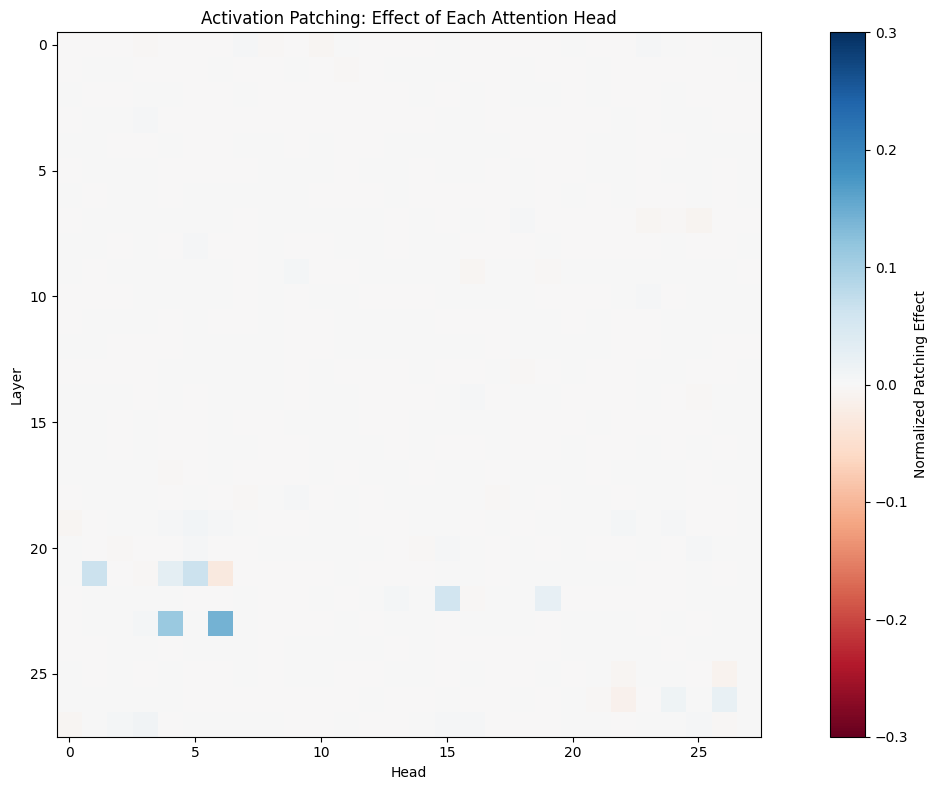

In [44]:

# Visualize as a heatmap
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(head_effects, cmap="RdBu", vmin=-0.3, vmax=0.3)
ax.set_xlabel("Head"); ax.set_ylabel("Layer")
ax.set_title("Activation Patching: Effect of Each Attention Head")
plt.colorbar(im, label="Normalized Patching Effect")
plt.tight_layout(); plt.savefig("head_patching.png", dpi=150)
plt.show()

### Reading the colormap first

- **Dark blue** → strong positive effect (~0.3) — patching this head with clean activations strongly restores "Paris". This head carries the factual information.
- **Light blue** → weak positive effect — this head helps a little.
- **White/very light** → near zero effect — this head is irrelevant for this task.
- **Orange/red** → negative effect — patching this head actually hurts the output, making it more "Warsaw-like". This is a head that was actively helping the corrupted run.

**Reading the raw data carefully:**

- **Layer 21** is where the story begins — heads 1 (0.064), 5 (0.065) are the first ones with meaningful effect. These heads are early movers, starting to write capital-city information into the stream.
- **Layer 22** — head 15 (0.058), head 19 (0.026) continue the process.
- **Layer 23** — head 4 (0.110) and head 6 (0.141) are your strongest individual contributors. These are the primary factual retrieval heads. Together they produce most of the causal effect you observed in the layer experiment.
- **Layers 24–27** — effects drop back to tiny values. These layers are not doing factual retrieval — they're doing output formatting, token prediction shaping, and similar late-stage processing. They benefit from the information already written by layers 21–23, but they don't independently carry it.




In [45]:
import torch
import numpy as np

---
## Technique 3: Causal Tracing (ROME-style)

**Goal:** Identify **where in the model** (which layer AND which token position) a specific fact is stored.

### How it works (3-step process)
1. **Clean run:** Run the clean prompt (`"The capital of France is"`) and cache all residual-stream activations.
2. **Corrupt + Restore:** For each `(layer, position)` pair:
   - Re-run the **same prompt** but add **Gaussian noise** to the subject token's embedding (`"France"` at position 4) to corrupt the model's "knowledge" of the subject.
   - Simultaneously, **restore** the clean residual-stream activation at exactly one `(layer, position)` cell.
3. **Measure:** Record the logit score for `" Paris"` — a high score means this cell is critical for the fact.

### Key difference from Layer Patching
- Layer patching uses a *different* corrupt prompt; causal tracing uses the *same* prompt with **added noise**.
- Causal tracing probes **both layer and token position** simultaneously, revealing a 2D "where is the fact stored" map.
- Bright spots in the heatmap = locations where clean information is needed to recover the answer.


In [46]:
# === Causal Tracing: Noise + Restore ===
prompt = "The capital of France is"
clean_logits, clean_cache = model.run_with_cache(prompt)
tokens = model.to_tokens(prompt)

In [47]:
print(tokens)
print(tokens[0][4])

print(model.to_string(tokens[0][3]))

tensor([[ 785, 6722,  315, 9625,  374]], device='cuda:0')
tensor(374, device='cuda:0')
 France


In [48]:
# Step 1: Corrupt by adding noise to the SUBJECT token embeddings
# "France" is the subject — find its position
subject_pos = 3  # adjust based on tokenization
noise_scale = 3.0 * clean_cache["blocks.0.hook_resid_pre"].std()

# Step 2: For each (layer, position), restore clean activation
n_layers = model.cfg.n_layers
n_pos = tokens.shape[1]
effects = np.zeros((n_layers, n_pos))

### Causal Tracing Loop

For each `(layer, position)` pair (28 × sequence_length combinations):
1. **`corrupt_embed` hook** at `blocks.0.hook_resid_pre`: adds noise to the subject token.
2. **`restore_hook`** at `blocks.<layer>.hook_resid_post`: restores the clean activation at `pos`.
3. Records the raw logit score (not normalized) for `" Paris"` at the final output position.


In [49]:
for layer in range(n_layers):
    for pos in range(n_pos):
        def corrupt_embed(activation, hook):
            # Add noise to subject token's embedding
            activation[:, subject_pos, :] += (
                torch.randn_like(activation[:, subject_pos, :]) * noise_scale
            )
            return activation

        def restore_hook(activation, hook, layer=layer, pos=pos):
            # Restore clean activation at this specific (layer, pos)
            activation[:, pos, :] = clean_cache[
                f"blocks.{layer}.hook_resid_post"
            ][:, pos, :]
            return activation

        patched_logits = model.run_with_hooks(
            prompt,
            fwd_hooks=[
                ("blocks.0.hook_resid_pre", corrupt_embed),
                (f"blocks.{layer}.hook_resid_post", restore_hook),
            ]
        )

        target_id = model.to_single_token(" Paris")
        effects[layer, pos] = patched_logits[0, -1, target_id].item()

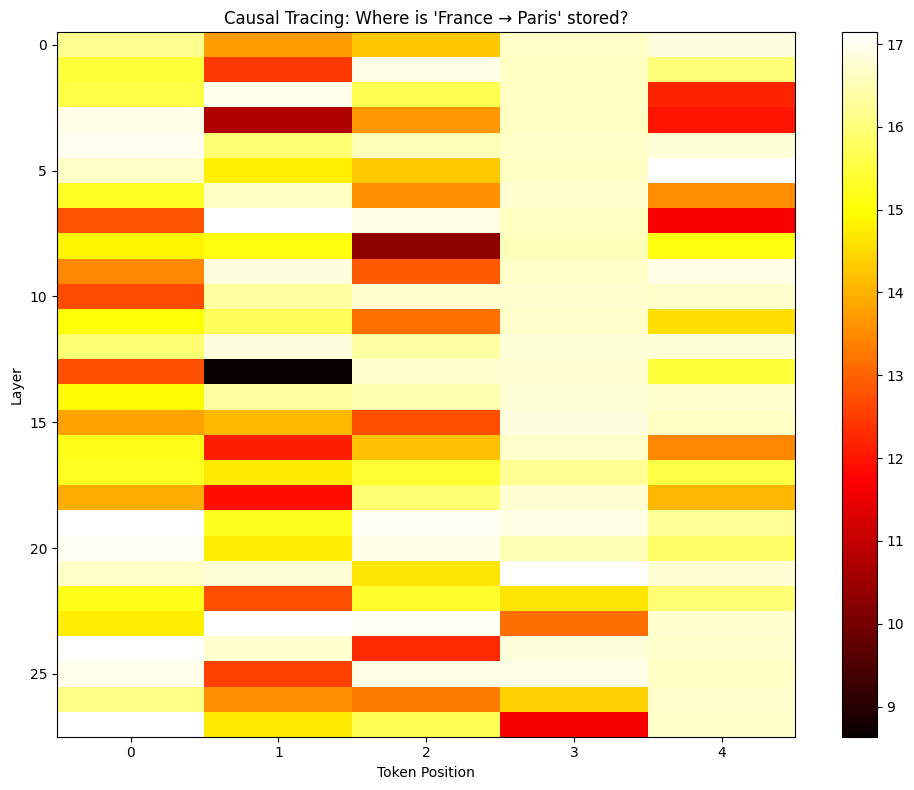

In [50]:
# Visualize: bright spots = critical (layer, position) combinations
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(effects, cmap="hot", aspect="auto")
ax.set_xlabel("Token Position"); ax.set_ylabel("Layer")
ax.set_title("Causal Tracing: Where is 'France → Paris' stored?")
plt.colorbar(im); plt.tight_layout()
plt.savefig("causal_tracing.png", dpi=150)
plt.show()

---
## ✅ Position Correction: `France` is at Position 3 (not 4)

The output above confirms it directly:
- `model.to_string(tokens[0][3])` → `" France"` ← **France is at index 3**
- `tokens[0][4]` → `374` → that is the token `" is"` (the last token)

So `subject_pos = 3` in the setup code below is **correct**.

| Position | Token | Role |
|---|---|---|
| 0 | `"The"` | article |
| 1 | `" capital"` | relation word |
| 2 | `" of"` | preposition |
| **3** | **`" France"`** | **← subject (the entity whose fact we are tracing)** |
| 4 | `" is"` | last token — this is where next-word prediction is generated |

---

## 🧠 What Is Causal Tracing Actually Trying To Find?

### The core question:
> **At which specific `(layer, token_position)` cell inside the model is the factual knowledge `"France → Paris"` stored and transmitted?**

Compared to **Layer Patching** (which told us *which layer* matters) and **Head Patching** (which told us *which attention head*), causal tracing adds a crucial second dimension: **which token position**. This reveals WHERE in the sequence the factual information flows.

---

## 🤔 Why Do We Add Noise ONLY to France's Position?

Think of it as a **targeted amnesia experiment**:

1. **France is the key to the fact.** The prompt `"The capital of ___ is"` is ambiguous — the answer depends entirely on the country. The tokens `"The"`, `"capital"`, `"of"`, `"is"` carry grammatical structure but NOT the specific factual knowledge. Only `"France"` determines that the answer must be `"Paris"` (not `"Warsaw"`, `"Berlin"`, etc.).

2. **Corrupting France's embedding = erasing the model's ability to identify the subject.** By adding strong Gaussian noise to position 3's activation at the very first layer (`blocks.0.hook_resid_pre`), we destroy the clean `"France"` signal before the model has a chance to use it. The model then outputs a wrong or uncertain answer.

3. **We do NOT corrupt other positions** because they don't carry the factual signal we want to trace. Corrupting `"The"` or `"capital"` would just confuse the grammar, not the fact about France.

---

## 🔬 What Does Restoring At Each `(layer, pos)` Tell Us?

After corrupting France's embedding, we run the model again — but this time we **surgically restore** the clean residual-stream activation at exactly ONE `(layer, position)` cell. Then we ask:

> *Did recovering that one cell allow the model to output `" Paris"` again?*

- **YES (high Paris logit)** → That `(layer, pos)` cell was **carrying the France→Paris factual signal** at that point in the computation. Restoring it let the model pick up where it left off.
- **NO (low Paris logit)** → The factual signal is NOT present at that location (either not computed yet, or already passed downstream).

This creates a **2D heatmap** (layer × token position) showing the exact information-flow path of the fact through the network.

---

## 🗺️ Reading the Heatmap

Colormap = `hot`: black → dark red → orange → yellow → white (low to high)

| Color | Meaning |
|---|---|
| **Bright (yellow/white)** | High Paris logit — restoring this cell RECOVERS the correct answer |
| **Dark (black/dark red)** | Low Paris logit — restoring this cell does NOT help |

### The expected information-flow circuit:

```
Position 3 ("France"), middle-to-late layers
  → MLP layers perform the "France → Paris" key-value lookup HERE
  → Bright spot expected at pos 3, layers ~18–23

Position 4 ("is"), late layers
  → Attention heads COPY the Paris signal from pos 3 to pos 4
  → Bright spot expected at pos 4, layers ~23–27

Unembedding at pos 4 → Output: " Paris"
```

If the heatmap shows bright at **pos 3 in middle layers** AND bright at **pos 4 in late layers**, it confirms the classic **MLP lookup → attention copy** circuit identified by the ROME paper (Meng et al., 2022) as the core mechanism for factual recall in large language models.

> **Note:** The colors you see are *raw Paris logit scores*, not normalized effects. Most cells will be somewhat bright because the model is large and has many redundant pathways. Look for *relative* peaks — the brightest cells tell the most interesting story.
